In [2]:
from copy import deepcopy
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

from mfsindy.cases.isothermal_flow import (
    NSIsothermalMultiTrajectoryGLSConfig,
    build_ns_isothermal_weak_validation_blocks,
    fit_ns_isothermal_multi_trajectory_coefficients,
    generate_isothermal_ns_dataset,
    get_ns_isothermal_feature_names,
    load_ns_part1_tuned_hyperparams,
    run_ns_isothermal_multi_trajectory_gls_experiment,
    save_ns_part1_tuned_hyperparams,
)
from mfsindy.cases.isothermal_flow_plots import COLORS_MODELS
from mfsindy.experiments import (
    evaluate_weak_form_models,
    format_coefficient_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_trajectory_list,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
if not RESULTS_DIR.exists():
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
elif not RESULTS_DIR.is_dir():
    raise NotADirectoryError(f"{RESULTS_DIR} exists and is not a directory")

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]

cfg = NSIsothermalMultiTrajectoryGLSConfig(
    n_runs=25,
    n_lf=100,
    n_hf=10,
    results_dir=str(RESULTS_DIR),
    results_filename="navierstokes_part1_errors.csv",
)


# Navier Stokes Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Isothermal Navier-Stokes equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The isothermal compressible Navier–Stokes equations are

$$
\begin{aligned}
\partial_t \rho + \nabla \cdot (\rho \mathbf{u}) &= 0 \\
\partial_t (\rho \mathbf{u}) + \nabla \cdot (\rho \mathbf{u}\otimes \mathbf{u}) + \nabla p &= \mu \Delta \mathbf{u},
\end{aligned}
$$

where $\rho(\mathbf{x},t)$ is the density, $\mathbf{u}(\mathbf{x},t)$ is the velocity field, $p$ is the pressure, and $\mu$ is the viscosity coefficient. Under the isothermal ideal-gas assumption, the pressure is given by the equation of state

$$
p = \rho R T,
$$

where $R$ is the specific gas constant and $T$ is the constant temperature

We use parameters $(\mu, c_s)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

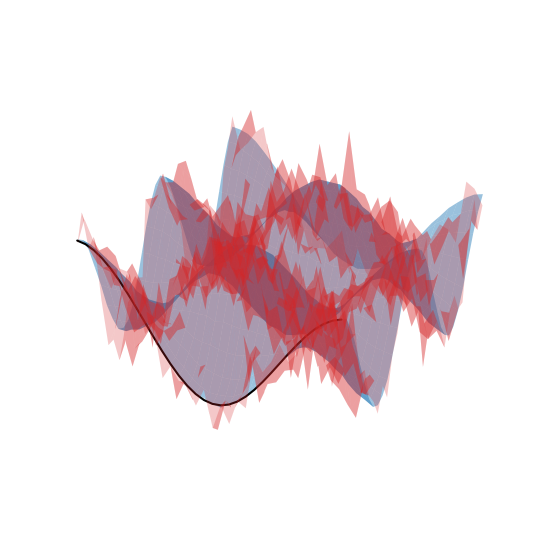

In [3]:
from mfsindy.cases.isothermal_flow_plots import plot_multifidelity_trajectories
U_ref, _, grid_ref = generate_isothermal_ns_dataset(
    N=cfg.N,
    Nt=cfg.Nt,
    L=cfg.L,
    T=cfg.T,
    mu=cfg.mu,
    RT=cfg.RT,
    seed=cfg.seed_base,
    ic_type="taylor-green",
)
state_std    = float(np.std(U_ref))
noise_hf_abs = cfg.noise_hf_rel * state_std
noise_lf_abs = cfg.noise_lf_rel * state_std

rng_hf = np.random.default_rng(cfg.seed_base + 1000)
rng_lf = np.random.default_rng(cfg.seed_base + 2000)

U_hf_noisy = U_ref + noise_hf_abs * rng_hf.standard_normal(U_ref.shape)
U_lf_noisy = U_ref + noise_lf_abs * rng_lf.standard_normal(U_ref.shape)

plot_multifidelity_trajectories(grid_ref, U_hf_noisy, U_lf_noisy, U_ref)


### Hyperparameter Selection

Use one HF/LF ensemble draw, split trajectories 80-20 into train and validation sets, tune the weak-form hyperparameters separately for each model by maximizing held-out weak-form $R^2$, then refit on the full ensemble and print the resulting equations.


In [4]:

# H_XY_CANDIDATES = [cfg.L / 20.0, cfg.L / 10.0, cfg.L / 5.0]
# H_T_CANDIDATES = [cfg.T / 20.0, cfg.T / 10.0, cfg.T / 5.0]

# SEARCH_GRID = {
#     "stlsq_threshold": [0.25, 0.5, 1.0],
#     "H_xt": [[h_xy, h_xy, h_t] for h_xy in H_XY_CANDIDATES for h_t in H_T_CANDIDATES],
# }

# U_ref_search, t_search, grid_search = generate_isothermal_ns_dataset(
#     N=cfg.N,
#     Nt=cfg.Nt,
#     L=cfg.L,
#     T=cfg.T,
#     mu=cfg.mu,
#     RT=cfg.RT,
#     seed=cfg.seed_base,
#     ic_type="taylor-green",
# )
# state_std = float(np.std(U_ref_search[:, :, :, 2]))
# noise_hf_abs = cfg.noise_hf_rel * state_std
# noise_lf_abs = cfg.noise_lf_rel * state_std

# def sample_noisy_trajectory(seed: int, noise_abs: float, *, noise_seed: int) -> np.ndarray:
#     U_clean, _, _ = generate_isothermal_ns_dataset(
#         N=cfg.N,
#         Nt=cfg.Nt,
#         L=cfg.L,
#         T=cfg.T,
#         mu=cfg.mu,
#         RT=cfg.RT,
#         seed=seed,
#         ic_type="taylor-green",
#     )
#     rng = np.random.default_rng(noise_seed)
#     return U_clean + noise_abs * rng.standard_normal(size=U_clean.shape)

# U_hf_search = [
#     sample_noisy_trajectory(
#         cfg.seed_base + j,
#         noise_hf_abs,
#         noise_seed=cfg.seed_base + 10_000 + j,
#     )
#     for j in range(cfg.n_hf)
# ]
# U_lf_search = [
#     sample_noisy_trajectory(
#         cfg.seed_base + 1_000 + j,
#         noise_lf_abs,
#         noise_seed=cfg.seed_base + 20_000 + j,
#     )
#     for j in range(cfg.n_lf)
# ]

# search_results = {}
# best_params_by_model = load_ns_part1_tuned_hyperparams(results_dir=RESULTS_DIR) or {}
# tuned_cfg_by_model = {}
# tuned_equations = {}

# if not best_params_by_model:
#     hf_train, hf_val = split_trajectory_list(U_hf_search, validation_fraction=0.2)
#     lf_train, lf_val = split_trajectory_list(U_lf_search, validation_fraction=0.2)

#     def evaluate_candidate(candidate_cfg):
#         coef_map = fit_ns_isothermal_multi_trajectory_coefficients(
#             candidate_cfg,
#             hf_trajectories=hf_train,
#             lf_trajectories=lf_train,
#             t_grid=t_search,
#             grid=grid_search,
#             noise_hf_abs=noise_hf_abs,
#             noise_lf_abs=noise_lf_abs,
#             weak_seed=candidate_cfg.seed_base + 40_000,
#         )
#         validation_blocks = (
#             build_ns_isothermal_weak_validation_blocks(
#                 candidate_cfg,
#                 hf_val,
#                 grid=grid_search,
#                 weak_seed=candidate_cfg.seed_base + 40_010,
#                 group_name="HF validation",
#             )
#             + build_ns_isothermal_weak_validation_blocks(
#                 candidate_cfg,
#                 lf_val,
#                 grid=grid_search,
#                 weak_seed=candidate_cfg.seed_base + 40_020,
#                 group_name="LF validation",
#             )
#         )
#         return evaluate_weak_form_models(coef_map, validation_blocks)

#     for target_model in MODELS:
#         search = optimize_hyperparams(
#             cfg,
#             param_grid=SEARCH_GRID,
#             evaluate=evaluate_candidate,
#             score_fn=make_metric_scorer(source=target_model, metric="weak_r2"),
#             maximize=True,
#         )
#         tuned_cfg = deepcopy(search.best_config)
#         search_results[target_model] = search
#         best_params_by_model[target_model] = search.best_params
#         tuned_cfg_by_model[target_model] = tuned_cfg

#     save_ns_part1_tuned_hyperparams(best_params_by_model, results_dir=RESULTS_DIR)

# for target_model in MODELS:
#     tuned_cfg = tuned_cfg_by_model.get(target_model, deepcopy(cfg))
#     if target_model not in tuned_cfg_by_model:
#         for name, value in best_params_by_model[target_model].items():
#             setattr(tuned_cfg, name, value)
#         tuned_cfg_by_model[target_model] = tuned_cfg
#     full_coef_map = fit_ns_isothermal_multi_trajectory_coefficients(
#         tuned_cfg,
#         hf_trajectories=U_hf_search,
#         lf_trajectories=U_lf_search,
#         t_grid=t_search,
#         grid=grid_search,
#         noise_hf_abs=noise_hf_abs,
#         noise_lf_abs=noise_lf_abs,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     tuned_equations[target_model] = full_coef_map[target_model]

# feature_names = get_ns_isothermal_feature_names(
#     cfg,
#     grid=grid_search,
#     reference_trajectory=U_ref_search,
# )
# print(pd.DataFrame(best_params_by_model).T)
# print(
#     format_coefficient_equations(
#         tuned_equations,
#         feature_names=feature_names,
#         state_names=("u_t", "v_t", "rho_t"),
#         precision=3,
#     )
# )


### Run

In [5]:
# df_errors_parts = []
# for model_name in MODELS:
#     method_cfg = deepcopy(tuned_cfg_by_model[model_name])
#     method_cfg.results_dir = str(RESULTS_DIR)
#     method_cfg.results_filename = f"navierstokes_part1_{model_name.lower()}_errors.csv"
#     df_model, _, _, _, _, _ = run_ns_isothermal_multi_trajectory_gls_experiment(method_cfg)
#     df_errors_parts.append(df_model[df_model["model"] == model_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# df_errors.to_csv(Path(cfg.results_dir) / cfg.results_filename, index=False)


## Errors

In [6]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)
def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.019815  0.004149  0.020609
LF     0.050645  0.041819  0.064936
MF     0.052649  0.044123  0.059485
MF_w   0.000189  0.000149  0.000214
Support Fraction Error
         median       q25       q75
model                              
HF     0.214286  0.142857  0.214286
LF     0.714286  0.571429  0.928571
MF     0.714286  0.642857  0.928571
MF_w   0.000000  0.000000  0.000000


### L1 Error

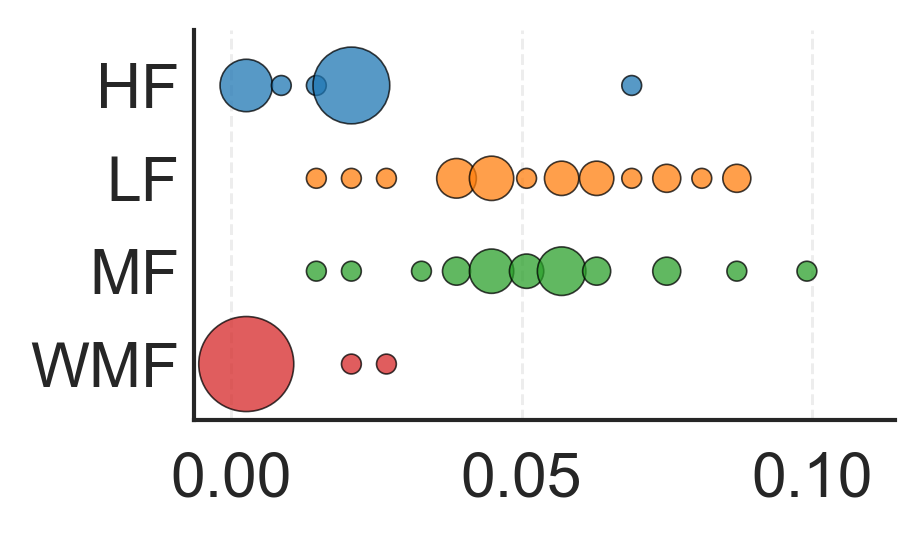

In [7]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
models = MODELS[3::-1]
labels = models.copy()
labels[0] = "WMF"
all_l1_values = np.concatenate([
    np.asarray(mae_errors[m], dtype=float)
    for m in models
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.01
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=mae_errors,
    n_bins=20,
    models_order=models,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_1",
)


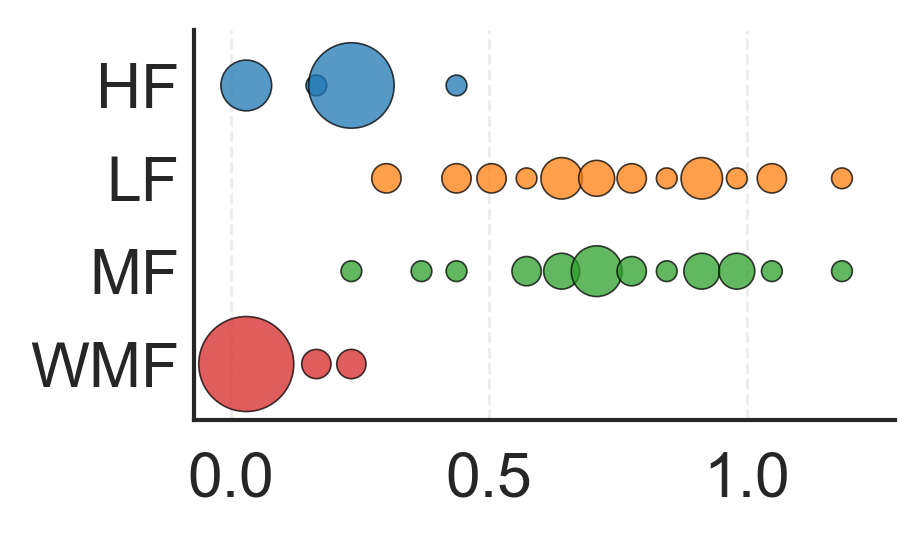

In [8]:
all_l0_values = np.concatenate([
    np.asarray(l0_errors[m], dtype=float)
    for m in models
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=l0_errors,
    n_bins=20,
    models_order=models,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_1"
)
